<a href="https://colab.research.google.com/github/Jhairzp27/VitalsFlow/blob/main/01_Exploracion_y_Diagnostico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Carga tu archivo
df = pd.read_csv('healthcare_dataset.csv')

# Inspección Visual y Estructural

In [2]:
print("Primeras 5 filas:")
display(df.head())

print("\nEstructura del dataset (Filas, Columnas):")
print(df.shape)

print("\nTipos de datos y valores no nulos:")
print(df.info())

Primeras 5 filas:


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal



Estructura del dataset (Filas, Columnas):
(55500, 15)

Tipos de datos y valores no nulos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Result

# Identificación de Problemas

In [3]:
print("Valores nulos por columna:")
print(df.isnull().sum())

print("\nRegistros duplicados:")
print(df.duplicated().sum())

print("\nValores únicos en columnas categóricas (Género, Tipo de Sangre, Condición):")
for col in ['Gender', 'Blood Type', 'Medical Condition']:
    print(f"{col}: {df[col].unique()}")

Valores nulos por columna:
Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

Registros duplicados:
534

Valores únicos en columnas categóricas (Género, Tipo de Sangre, Condición):
Gender: ['Male' 'Female']
Blood Type: ['B-' 'A+' 'A-' 'O+' 'AB+' 'AB-' 'B+' 'O-']
Medical Condition: ['Cancer' 'Obesity' 'Diabetes' 'Asthma' 'Hypertension' 'Arthritis']


### Visualización y caza de nulos ocultos

--- CAZA DE NULOS OCULTOS ---
Búsqueda de textos sospechosos finalizada.

--- ANÁLISIS DE VALORES NUMÉRICOS ---
Edad mínima: 13 | Edad máxima: 89
Facturación mínima: -2008.4921398591305 | Facturación máxima: 52764.276736469175



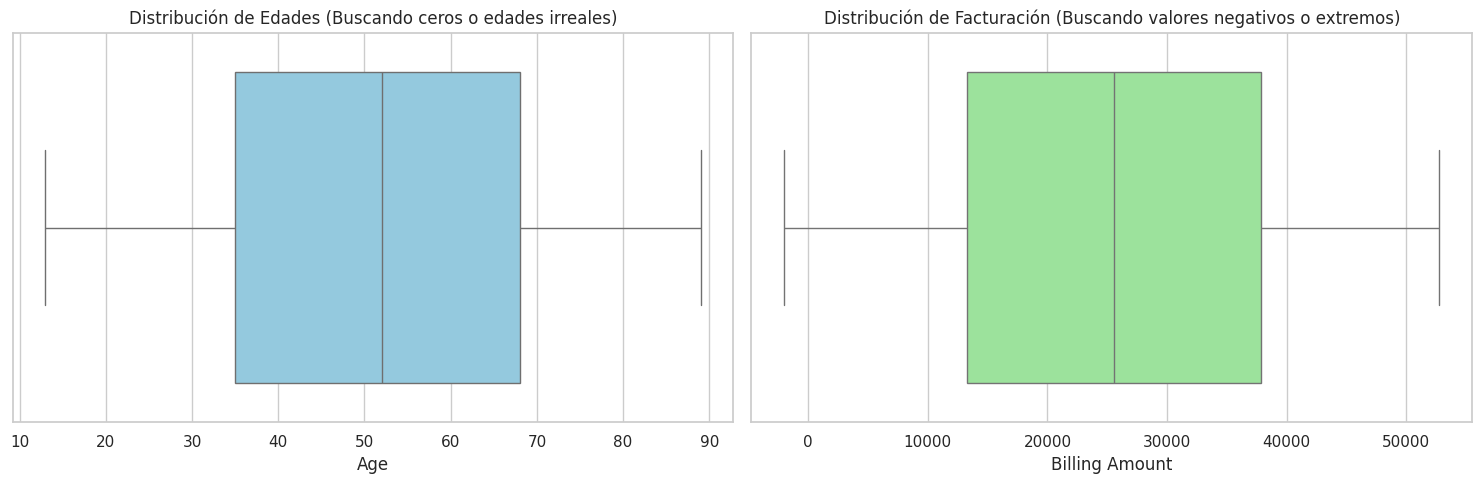

In [4]:
# Configuramos el estilo de los gráficos
sns.set_theme(style="whitegrid")

print("--- CAZA DE NULOS OCULTOS ---")
# Buscamos strings vacíos o palabras comodín en las columnas de texto
for col in df.select_dtypes(include=['object']).columns:
    sospechosos = df[df[col].astype(str).str.strip().isin(['', 'N/A', 'None', 'Unknown', '-', 'null'])]
    if len(sospechosos) > 0:
        print(f"⚠️ ¡Ojo! La columna '{col}' tiene {len(sospechosos)} valores sospechosos ocultos.")
print("Búsqueda de textos sospechosos finalizada.\n")

print("--- ANÁLISIS DE VALORES NUMÉRICOS ---")
print(f"Edad mínima: {df['Age'].min()} | Edad máxima: {df['Age'].max()}")
print(f"Facturación mínima: {df['Billing Amount'].min()} | Facturación máxima: {df['Billing Amount'].max()}\n")

# Gráficos (Boxplots) para ver la distribución de la data numérica
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(x=df['Age'], ax=axes[0], color='skyblue')
axes[0].set_title('Distribución de Edades (Buscando ceros o edades irreales)')

sns.boxplot(x=df['Billing Amount'], ax=axes[1], color='lightgreen')
axes[1].set_title('Distribución de Facturación (Buscando valores negativos o extremos)')

plt.tight_layout()
plt.show()

Al tener una facturación en negativo, me adentro a revisar

In [5]:
# Filtramos el DataFrame para ver solo las facturas menores a 0
facturas_negativas = df[df['Billing Amount'] < 0]

print(f"Encontramos {len(facturas_negativas)} registro(s) con facturación negativa.")
display(facturas_negativas)

Encontramos 108 registro(s) con facturación negativa.


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
132,ashLEy ERIcKSoN,32,Female,AB-,Cancer,2019-11-05,Gerald Hooper,"and Johnson Moore, Branch",Aetna,-502.507813,376,Urgent,2019-11-23,Penicillin,Normal
799,CHRisTOPHer wEiss,49,Female,AB-,Asthma,2023-02-16,Kelly Thompson,Hunter-Hughes,Aetna,-1018.245371,204,Elective,2023-03-09,Penicillin,Inconclusive
1018,AsHley WaRnER,60,Male,A+,Hypertension,2021-12-21,Andrea Bentley,"and Wagner, Lee Klein",Aetna,-306.364925,426,Elective,2022-01-11,Ibuprofen,Normal
1421,JAY galloWaY,74,Female,O+,Asthma,2021-01-20,Debra Everett,Group Peters,Blue Cross,-109.097122,381,Emergency,2021-02-09,Ibuprofen,Abnormal
2103,josHUa wilLIamSon,72,Female,B-,Diabetes,2021-03-21,Wendy Ramos,"and Huff Reeves, Dennis",Blue Cross,-576.727907,369,Urgent,2021-04-17,Aspirin,Abnormal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52894,JosEPh cOx,23,Male,AB-,Diabetes,2019-10-13,Peter Smith,Inc Ward,Blue Cross,-353.865186,271,Elective,2019-10-25,Lipitor,Inconclusive
53204,AsHley WaRnER,55,Male,A+,Hypertension,2021-12-21,Andrea Bentley,"and Wagner, Lee Klein",Aetna,-306.364925,426,Elective,2022-01-11,Ibuprofen,Normal
53232,dAnIel dRaKe,68,Female,B+,Hypertension,2020-04-24,Brett Ray,Carr Ltd,Aetna,-591.917419,426,Elective,2020-04-26,Lipitor,Abnormal
54136,DR. micHaEl MckAy,64,Male,O+,Cancer,2019-05-31,Dawn Navarro,"Mcconnell and Rios, Clark",UnitedHealthcare,-199.663795,122,Urgent,2019-06-12,Ibuprofen,Abnormal
